In [1]:
import warnings

warnings.filterwarnings('ignore')
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

import matplotlib.pyplot as plt
import os
import torch
from utils.graph_construction import cal_spatial_network
from scipy.sparse import bmat
from graph import AlignDG

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sc.set_figure_params(figsize=(4, 4))
os.environ['R_HOME'] = 'C:/Program Files/R/R-4.3.1'

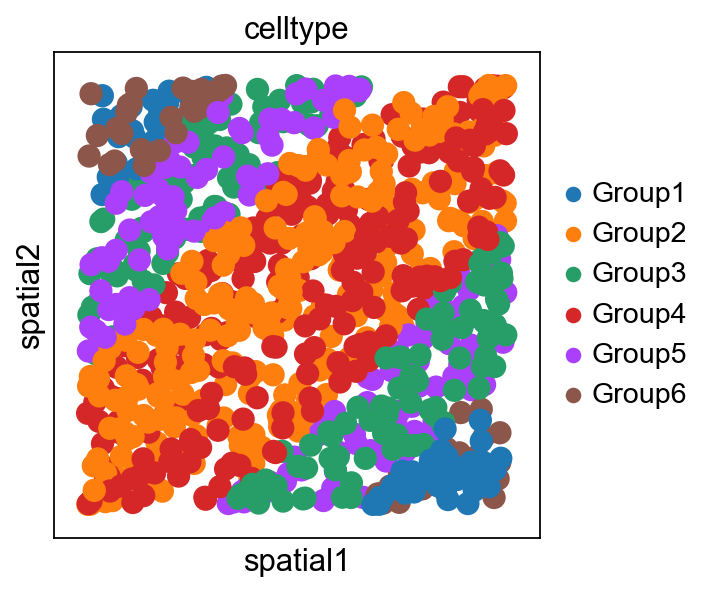

In [3]:
adata = sc.read_h5ad('../data/simulate2.h5ad')
sc.pl.spatial(adata, color=['celltype'], spot_size=0.5)
adata_sub1 = adata[adata.obs['batch'] == 'Batch1']
adata_sub2 = adata[adata.obs['batch'] == 'Batch2']

In [4]:
adata1_harm_df = pd.DataFrame({
    'index': range(adata_sub1.shape[0]),
    'x': adata_sub1.obsm['spatial'][:, 0],
    'y': adata_sub1.obsm['spatial'][:, 1],
    'domain': adata_sub1.obs['celltype'].astype('category'),
})

adata2_harm_df = pd.DataFrame({
    'index': range(adata_sub2.shape[0]),
    'x': adata_sub2.obsm['spatial'][:, 0],
    'y': adata_sub2.obsm['spatial'][:, 1],
    'domain': adata_sub2.obs['celltype'].astype('category'),
})

adata1_harm_df, adata2_harm_df

(         index         x         y  domain
 Cell1        0  3.462276  7.739260  Group2
 Cell2        1  2.738255  0.538378  Group3
 Cell3        2  2.122520  3.090184  Group3
 Cell4        3  3.679400  1.013588  Group3
 Cell5        4  3.329445  8.720741  Group5
 ...        ...       ...       ...     ...
 Cell496    495  1.523930  5.891787  Group4
 Cell497    496  1.170893  3.068123  Group3
 Cell498    497  8.295565  2.461201  Group2
 Cell499    498  0.183180  5.762538  Group3
 Cell500    499  5.888528  0.032188  Group3
 
 [500 rows x 4 columns],
           index         x         y  domain
 Cell501       0  5.389854  7.973142  Group3
 Cell502       1  2.894942  0.217818  Group5
 Cell503       2  5.560952  0.175539  Group5
 Cell504       3  3.267509  5.258370  Group2
 Cell505       4  6.734183  5.835438  Group3
 ...         ...       ...       ...     ...
 Cell996     495  0.867594  7.592023  Group2
 Cell997     496  0.907111  4.559816  Group5
 Cell998     497  5.934537  5.666909  Gr

In [5]:
adj_list = []
section_ids = ['Batch1', 'Batch2']
adata_list = [adata_sub1, adata_sub2]
for i in range(len(adata_list)):
    adata_list[i].X = sparse.csc_matrix(adata_list[i].X)
    adata_list[i].var_names_make_unique(join="++")
    adata_list[i].obs_names = [x + '_' + section_ids[i] for x in adata_list[i].obs_names]
    cal_spatial_network(adata_list[i], model='KNN', k_cutoff=2)
    adj_list.append(adata_list[i].uns['adj'])

Calculating spatial neighbor graph ...
The graph contains 1196 edges, 500 cells
2.392 neighbors per cell on average
Calculating spatial neighbor graph ...
The graph contains 1208 edges, 500 cells
2.416 neighbors per cell on average


In [6]:
from scipy.sparse import block_diag

adata_concat = ad.concat(adata_list, label='slice_name', keys=section_ids)
adj_concat = block_diag(adj_list)
adata_concat.uns['edge_list'] = np.nonzero(adj_concat)
adata_concat

AnnData object with n_obs × n_vars = 1000 × 500
    obs: 'celltype', 'batch', 'slice_name', 'batch_name'
    uns: 'edge_list'
    obsm: 'spatial'

In [7]:
adata_concat, pis = AlignDG.train_AlignDG(adata=adata_concat, beta=0.5, iter_comb=[(0, 1)])
print(adata_concat)

  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplet at epoch 500
Processing datasets ('Batch1', 'Batch2')
Solver may not converge.


# Epoch 599, loss: 0.413, gene_recon: 0.324, triplet loss: 0.08890863507986069:  18%|█▊        | 89/500 [00:16<00:21, 19.26it/s] 

Update spot triplet at epoch 600
Processing datasets ('Batch1', 'Batch2')


# Epoch 604, loss: 0.658, gene_recon: 0.434, triplet loss: 0.22376838326454163:  20%|██        | 101/500 [00:31<02:11,  3.02it/s]

...

Update spot triplet at epoch 900
Processing datasets ('Batch1', 'Batch2')


# Epoch 903, loss: 0.423, gene_recon: 0.248, triplet loss: 0.17502424120903015:  79%|███████▉  | 394/500 [01:16<00:05, 20.12it/s] 

Solver may not converge.


# Epoch 999, loss: 0.204, gene_recon: 0.181, triplet loss: 0.02287023700773716: 100%|██████████| 500/500 [01:16<00:00,  6.50it/s] 


AnnData object with n_obs × n_vars = 1000 × 500
    obs: 'celltype', 'batch', 'slice_name', 'batch_name'
    uns: 'edge_list'
    obsm: 'spatial', 'raw_latent', 'latent'


In [8]:
mapping_pi = pis[0]
count = 0
ref_raw_list = []
index = []
for i in range(mapping_pi.shape[0]):
    if np.sum(mapping_pi[i] > 0):
        index.append(i)
        source_domain = adata_sub1.obs['celltype'][i]
        max_align = mapping_pi[i].argsort()[-1]
        target_domain = adata_sub2.obs['celltype'].values[max_align]
        ref_raw_list.append(max_align)
        if source_domain == target_domain:
            count = count + 1

print(count / len(ref_raw_list), count, len(ref_raw_list))

index_harm = np.array(ref_raw_list)
matching_harm = np.array([index, index_harm])

0.954 477 500


In [9]:
def get_ratio_unbalanced(alignment, labels):
    matched_idx_list = []
    ad1_match_label = []
    ad2_match_label = [2] * alignment.shape[1]

    unique_labels_slice1 = set(labels[:alignment.shape[0]])
    unique_labels_slice2 = set(labels[alignment.shape[0]:])
    common_labels = unique_labels_slice1.intersection(unique_labels_slice2)

    indices_slice1 = [i for i in range(alignment.shape[0]) if labels[i] in common_labels]

    for i in indices_slice1:
        elem = alignment[i]
        max_idx = elem.argmax()
        matched_idx = max_idx + alignment.shape[0]

        if labels[i] == labels[matched_idx]:
            ad1_match_label.append(1)
            ad2_match_label[max_idx] = 1
            matched_idx_list.append(max_idx)
        else:
            ad1_match_label.append(0)
            ad2_match_label[max_idx] = 0
    return len(indices_slice1) / len(set(matched_idx_list))

In [10]:
get_ratio_unbalanced(alignment=np.array(mapping_pi), labels=adata_concat.obs['celltype'])

1.1312217194570136

dataset1: 6 cell types; dataset2: 6 cell types; 
                    Total :6 celltypes; Overlap: 6 cell types 
                    Not overlap :[[]]
Subsampled 150 pairs from 500


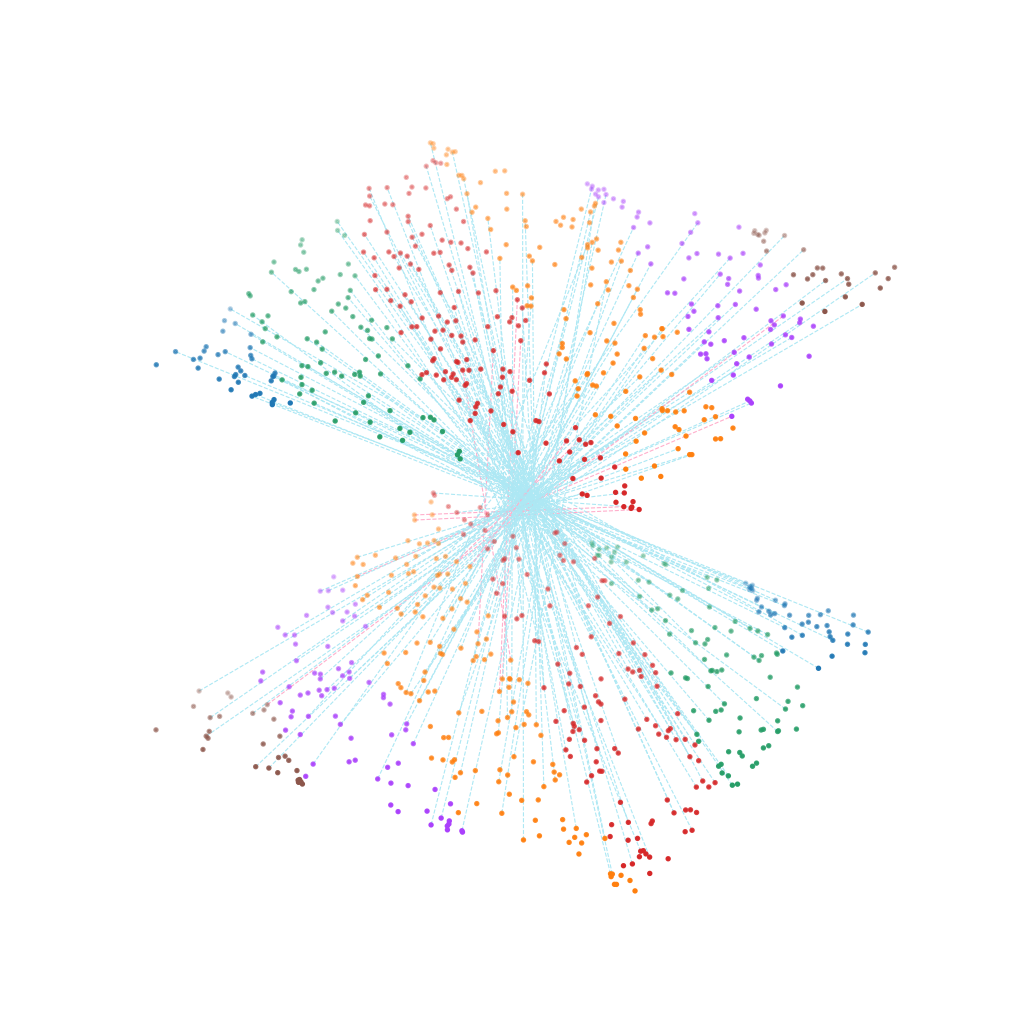

In [11]:
from utils.visualize import Build3D

multi_align = Build3D(adata2_harm_df, adata1_harm_df, matching_harm, meta='domain', scale_coordinate=True,subsample_size=150, exchange_xy=False)
multi_align.draw_3D(size=[8, 10], line_width=0.5, point_size=[2, 2], line_alpha=1, hide_axis=True, show_error=True)